# Segmentation

## Init

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
# from ModSegment import main2d, main3d
from ModSegment import (
    probabilistically_combine,
    colors,
    calc_jerk_in_time,
    signed_norm,
    moving_average,
    calc_acceleration,
    detect_brutal_changes,
)
from utils import read_robot_data
import downsampling as ds

pygame 2.6.1 (SDL 2.32.50, Python 3.11.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


## Segment data

In [3]:
def segment(
    time,
    data,
    base_thresh=1000,
    segment_size=10,
    window_size=64,
    grace_thresh=32,
    plot=False,
    mode="variations",
):
    """
    Detects changepoints in the given data based on the jerk values.
    Parameters:
    - time (array-like): The time values corresponding to the data.
    - data (array-like): The data to be segmented.
    - base_thresh (int, optional): The threshold value for segment detection. Defaults to 1000.
    - segment_size (int, optional): The size of each segment. Defaults to 256.
    - window_size (int, optional): The size of the moving average window. Defaults to 64.
    - grace_thresh (int, optional): The grace threshold for segment detection. Defaults to 32.
    - plot (bool, optional): Whether to plot the detected changepoints. Defaults to False.
    Returns:
    - segments (list): A list of indices indicating the detected changepoints in the data.
    """

    # Verificar que time y data tengan la misma longitud
    if len(time) != len(data):
        raise ValueError(
            "El tamaño del array de tiempo no coincide con el tamaño del array de datos."
        )

    # Comprobar si existen valores NaN
    if np.isnan(time).any() or np.isnan(data).any():
        raise ValueError("Existen valores NaN en los datos o en el tiempo.")

    # Verificar que los parámetros son válidos
    if base_thresh < 0 or segment_size <= 0 or window_size <= 0 or grace_thresh < 0:
        raise ValueError("Los valores de los parámetros no son válidos.")

    jerk = calc_jerk_in_time(time, data)
    total_jerk = signed_norm(jerk)
    avg_jerk = moving_average(total_jerk, window_size)
    norm_avg_jerk = avg_jerk / np.max(avg_jerk)

    # *Acceleration
    acceleration = calc_acceleration(time, data)
    total_acceleration = signed_norm(acceleration)
    avg_acceleration = moving_average(total_acceleration, window_size)
    norm_avg_acceleration = avg_acceleration / np.max(avg_acceleration)

    # * Two different types of segmentation
    if mode == "variations":
        segments = detect_brutal_changes(
            norm_avg_jerk, base_thresh, segment_size, norm_avg_acceleration
        )
    elif mode == "threshold":
        segments = count_thresh(
            norm_avg_jerk,
            base_thresh,
            segment_size,
            grace_thresh,
            norm_avg_acceleration,
        )
    else:
        raise ValueError("Invalid Mode")
    if plot:
        # Crear el gráfico
        plt.figure(figsize=(12, 6))
        plt.plot(norm_avg_jerk, label="Norm Avg Jerk", color="blue")
        plt.scatter(
            segments, norm_avg_jerk[segments], color="red", label="Keypoints", zorder=5
        )  # Puntos de segmentos
        plt.title("Normalized Avg Jerk Values with Marked Segments")
        plt.xlabel("Index")
        plt.ylabel("Norm Avg Jerk")
        plt.axhline(
            0, color="gray", linestyle="--", linewidth=0.8
        )  # Línea horizontal en y=0
        plt.legend()
        plt.grid()
        plt.show()

        # Crear el gráfico
        plt.figure(figsize=(12, 6))
        plt.plot(norm_avg_acceleration, label="Norm Avg Acceleration", color="blue")
        plt.scatter(
            segments,
            norm_avg_acceleration[segments],
            color="red",
            label="Keypoints",
            zorder=5,
        )  # Puntos de segmentos
        plt.title("Normalized Avg Acceleration Values with Marked Segments")
        plt.xlabel("Index")
        plt.ylabel("Norm Avg Acceleration")
        plt.axhline(
            0, color="gray", linestyle="--", linewidth=0.8
        )  # Línea horizontal en y=0
        plt.legend()
        plt.grid()
        plt.show()

    for i in range(1, len(segments)):
        segments[i] = segments[i] + window_size // 2

    if plot:
        fig = plt.figure(figsize=(7, 6))
        plt.title("Changepoint Detection")
        color_ind = 0
        for i in range(len(norm_avg_jerk)):
            plt.plot(i, norm_avg_jerk[i], colors[color_ind % len(colors)] + ".", ms=12)
            if color_ind < len(segments):
                if segments[color_ind] == i:
                    color_ind = color_ind + 1
        plt.xlabel("Time")
        plt.ylabel("Jerk")
        plt.show()

    return segments

In [4]:
def main3d(i):
    """
    This function performs 3D segmentation and visualization of robot data.
    It reads robot data from a specified file, performs segmentation on different data streams,
    and probabilistically combines the segments. Finally, it visualizes the trajectory in a 3D plot.
    """

    seed = 440773
    np.random.seed(seed)
    fname = f"../h5 files/vaso_data_{i + 1}.h5"
    joint_data, tf_data, wrench_data, gripper_data = read_robot_data(fname)

    joint_time = joint_data[0][:, 0] + joint_data[0][:, 1] * (10.0**-9)
    joint_pos = np.unwrap(joint_data[1], axis=0)

    traj_time = tf_data[0][:, 0] + tf_data[0][:, 1] * (10.0**-9)
    traj_pos = tf_data[1]
    # t.sleep(1000)

    wrench_time = wrench_data[0][:, 0] + wrench_data[0][:, 1] * (10.0**-9)
    wrench_frc = wrench_data[1]

    gripper_time = gripper_data[0][:, 0] + gripper_data[0][:, 1] * (10.0**-9)
    gripper_pos = gripper_data[1]

    traj_pos, ds_inds = ds.DouglasPeuckerPoints2(traj_pos, 1000)

    joint_time = joint_time[ds_inds]
    joint_pos = joint_pos[ds_inds, :]
    traj_time = traj_time[ds_inds]
    wrench_time = wrench_time[ds_inds]
    wrench_frc = wrench_frc[ds_inds, :]
    gripper_time = gripper_time[ds_inds]
    gripper_pos = gripper_pos[ds_inds]

    print("Joint Positions")
    thresh = 0.35
    ssize = 32
    wsize = 64
    gthresh = 32
    joint_segments = segment(
        joint_time,
        joint_pos,
        base_thresh=thresh,
        segment_size=ssize,
        window_size=wsize,
        grace_thresh=gthresh,
        plot=False,
    )

    print("Trajectory")
    thresh = 0.25
    ssize = 32
    wsize = 64
    gthresh = 32
    traj_segments = segment(
        traj_time,
        traj_pos,
        base_thresh=thresh,
        segment_size=ssize,
        window_size=wsize,
        grace_thresh=gthresh,
        plot=False,
    )

    print("Wrench Force")
    thresh = 0.15
    ssize = 32
    wsize = 64
    gthresh = 32
    frc_segments = segment(
        wrench_time,
        wrench_frc,
        base_thresh=thresh,
        segment_size=ssize,
        window_size=wsize,
        grace_thresh=gthresh,
        plot=False,
    )

    print("Gripper")
    thresh = 0.25
    ssize = 32
    wsize = 64
    gthresh = 32
    gripper_segments = segment(
        gripper_time,
        gripper_pos,
        base_thresh=thresh,
        segment_size=ssize,
        window_size=wsize,
        grace_thresh=gthresh,
        plot=False,
    )

    # segments = probabilistically_combine([traj_segments], len(traj_pos), 1, n_samples=50, n_pass=2, plot=True)
    segments = [traj_segments]
    return segments, traj_pos

In [5]:
i = 0
fname = f"../h5 files/vaso_data_{i + 1}.h5"
joint_data, tf_data, wrench_data, gripper_data = read_robot_data(fname)

['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


In [6]:
joint_time = joint_data[0][:, 0] + joint_data[0][:, 1] * (10.0**-9)
joint_pos = np.unwrap(joint_data[1], axis=0)

traj_time = tf_data[0][:, 0] + tf_data[0][:, 1] * (10.0**-9)
traj_pos = tf_data[1]
# t.sleep(1000)

wrench_time = wrench_data[0][:, 0] + wrench_data[0][:, 1] * (10.0**-9)
wrench_frc = wrench_data[1]

gripper_time = gripper_data[0][:, 0] + gripper_data[0][:, 1] * (10.0**-9)
gripper_pos = gripper_data[1]
traj_pos.shape

(3804, 3)

In [7]:
traj_pos, ds_inds = ds.DouglasPeuckerPoints2(traj_pos, 1000)
traj_pos.shape

(1000, 3)

## Combine segments

Demo 0
['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']
Joint Positions
Segmentos detectados: [30, 38, 125, 126, 190, 265, 356, 357, 358, 422, 449, 521, 531, 595, 596, 660, 688, 799, 802, 872, 918, 928, 931, 932]
Trajectory
Segmentos detectados: [349, 364, 429, 465, 529, 530, 694, 718, 719, 782, 793, 814, 878, 932]
Wrench Force
Segmentos detectados: [9, 48, 73, 79, 103, 167, 176, 177, 209, 230, 231, 249, 250, 251, 255, 276, 280, 288, 295, 316, 342, 344, 380, 406, 414, 513, 585, 600, 664, 667, 928, 932]
Gripper
Segmentos detectados: [2, 3, 15, 18, 44, 57, 147, 304, 368, 615, 775, 816, 820, 884, 885, 886, 893, 912, 929, 932]
[[349, 396, 461, 497, 561, 562, 726, 750, 751, 814, 825, 846, 910, 964]]
Segmentos 0: [[349, 396, 461, 497, 561, 562, 726, 750, 751, 814, 825, 846, 910, 964]]
Demo 1
['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']
Joint Positions
Segmentos detectados: [40, 41, 104, 105, 138, 158, 222, 223, 227, 230, 237, 318, 330, 331, 337, 

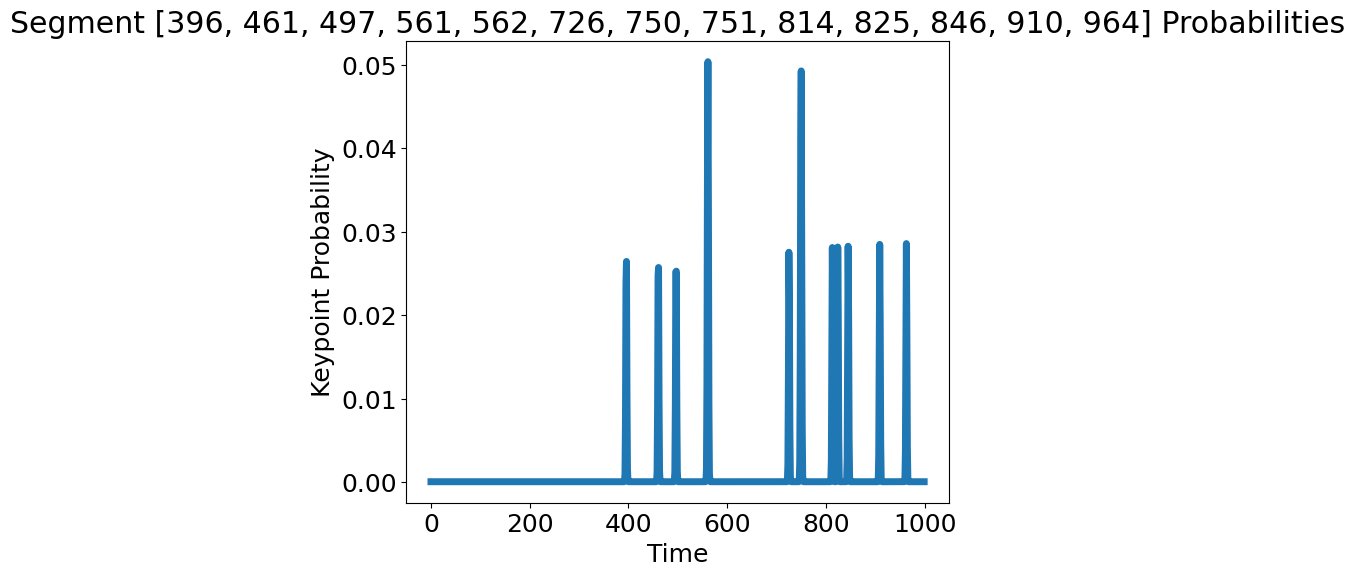

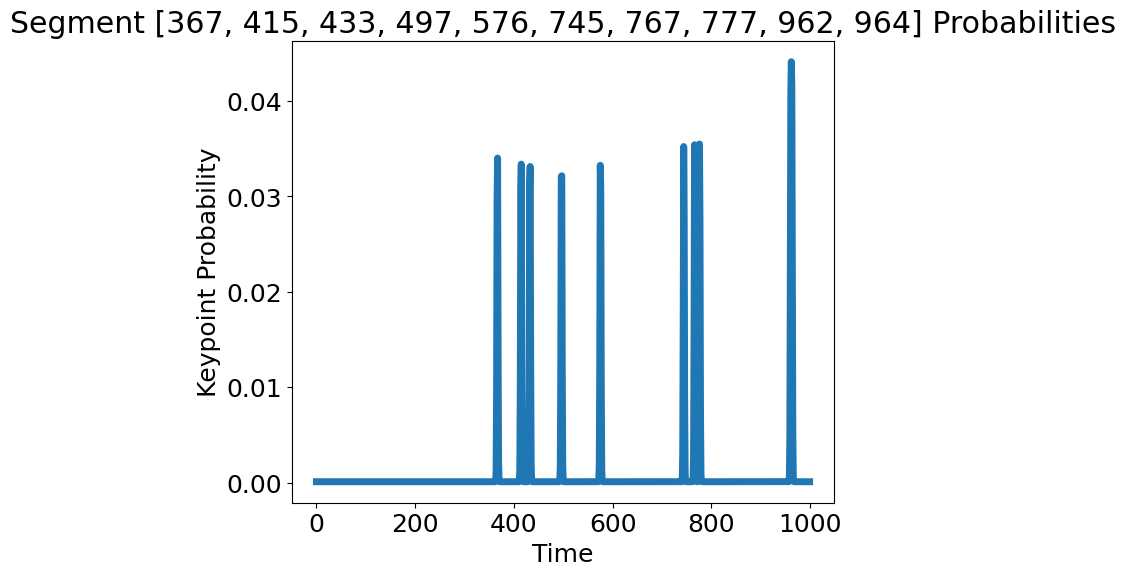

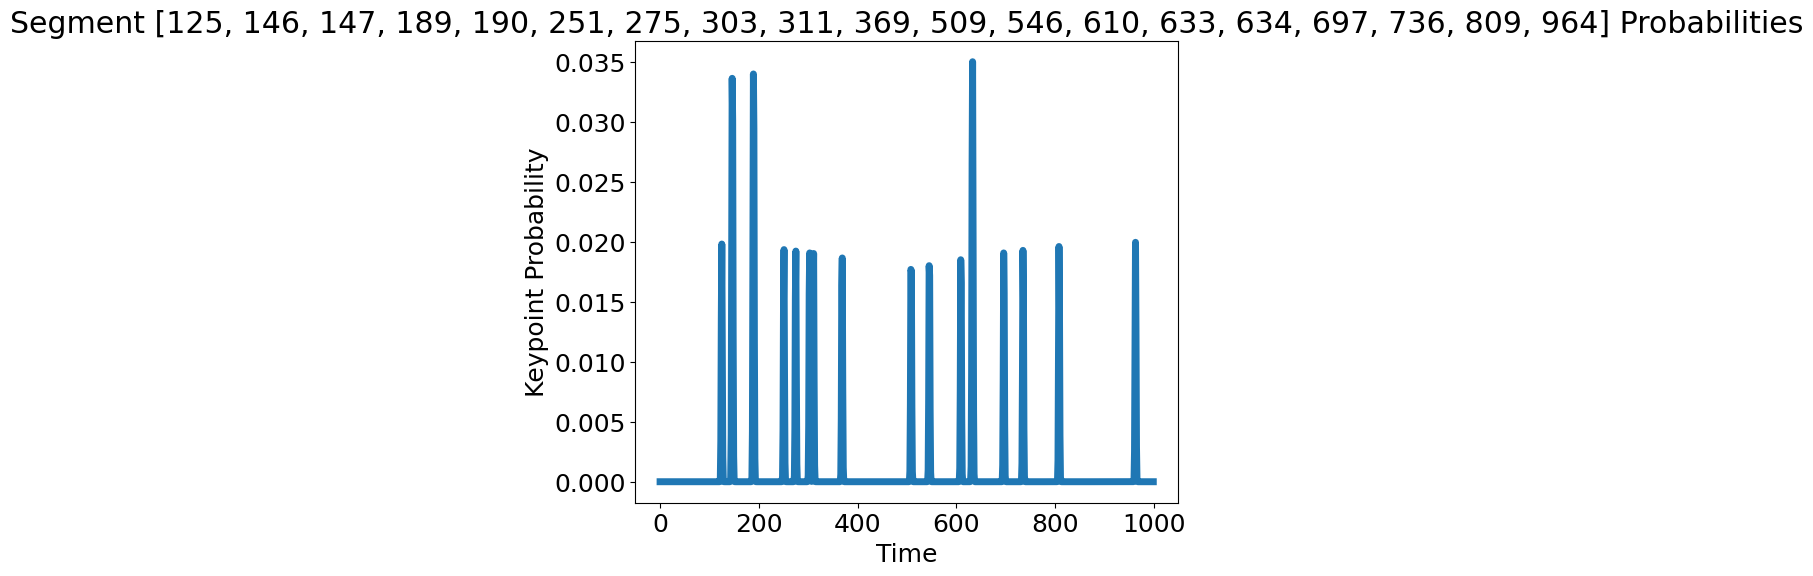

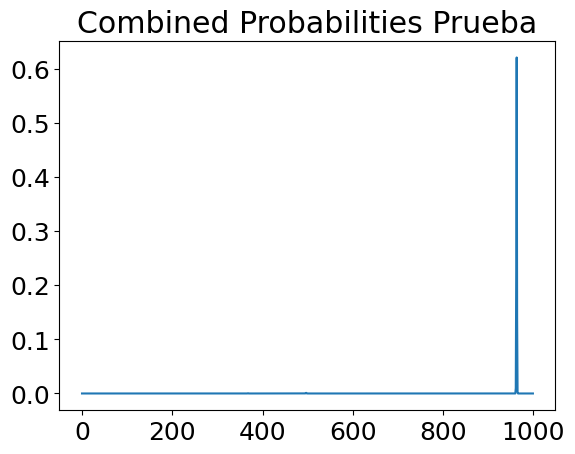

[125 146 189 251 275 303 311 368 396 415 433 461 497 508 545 561 575 609
 633 696 725 735 744 747 750 766 776 808 811 813 824 845 909 963]


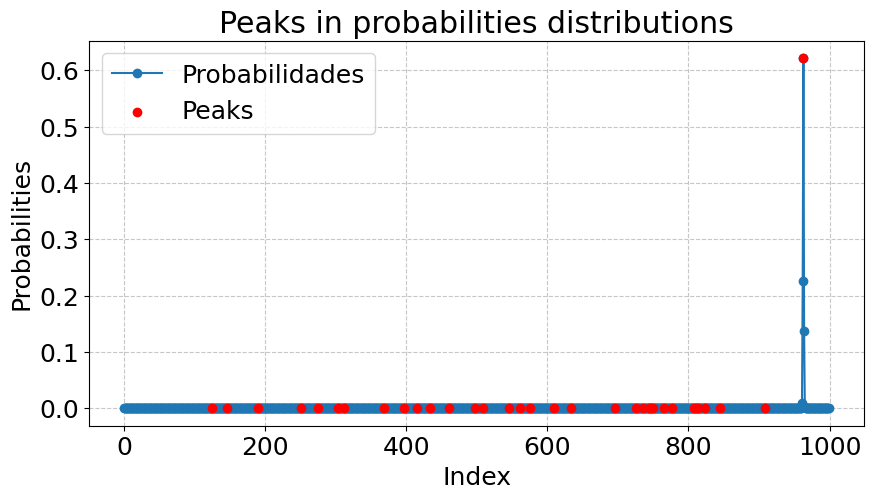

Sorted Keypoints [   0  125  146  189  251  275  303  311  368  396  415  433  461  497
  508  545  561  575  609  633  696  725  735  744  747  750  766  776
  808  811  813  824  845  909  963 1000]
Valor de final keys [164]
Valor de final keys [164, 447]
Valor de final keys [164, 447, 752]
164
Final Keypoints Obtained
[   0  447  752 1000]
Final Segments


/tmp/ipykernel_1986789/4123466830.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


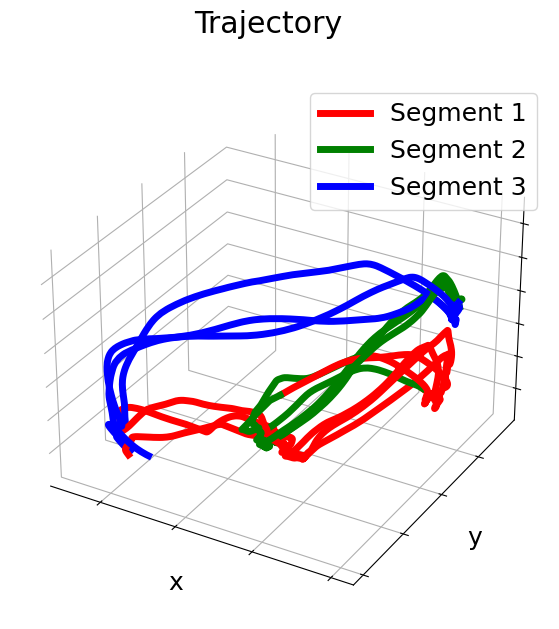

In [8]:
# mode = 2 #* Mode of execution, it can be 2D or 3D
mode = 3  # * Mode of execution, it can be 2D or 3D

all_segments = []
all_demos = []
segment_data = []

# ?Segmentation in 3D
if mode == 3:
    for i in range(3):  # * Number of demos
        print(f"Demo {i}")
        segments, demo = main3d(i=i)
        print(segments)
        all_segments.extend(
            segments
        )  # * use extend if you use multimodal demonstrations
        all_demos.append(demo)
        print(f"Segmentos {i}:", segments)
    # Concatenar todos los segmentos en un solo array
    # all_segments_flat = np.concatenate(all_segments).reshape(-1, 1)
    segments = probabilistically_combine(
        all_segments, len(demo), 1, n_samples=50, n_pass=2, plot=True
    )
    # segments = all_segments
    print("Final Segments")
    # Figura para visualizar los segmentos
    plt.rcParams["figure.figsize"] = (9, 7)
    fig = plt.figure()
    fig.suptitle("Trajectory")
    ax = plt.axes(projection="3d")
    for j in range(len(all_demos)):
        demo = all_demos[j]

        # Aquí guardamos los segmentos de esta demo
        demo_segments = []

        for i in range(len(segments) - 1):
            segment = demo[segments[i] : segments[i + 1], :]
            demo_segments.append(segment)

            # * Draw each segments

            ax.plot3D(
                demo[segments[i] : segments[i + 1], 0],
                demo[segments[i] : segments[i + 1], 1],
                demo[segments[i] : segments[i + 1], 2],
                c=colors[i],
                label="Segment " + str(i + 1) if j == 0 else "",
                lw=5,
            )
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            ax.set_zlabel("z")
            # First remove fill
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            # Now set color to white (or whatever is "invisible")
            ax.xaxis.pane.set_edgecolor("w")
            ax.yaxis.pane.set_edgecolor("w")
            ax.zaxis.pane.set_edgecolor("w")
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_zticklabels([])
            ax.legend()
            plt.tight_layout()

        segment_data.append(demo_segments)

    plt.show()

# # ? Segmentation in 2D
# elif mode == 2:
#     for i in range(3):  # * Number of demos
#         print(f"Demo {i}")
#         segments, demo = main2d(i=i)
#         all_segments.append(segments)
#         all_demos.append(demo)
#         print(f"Segmentos {i}:", segments)
#     # Concatenar todos los segmentos en un solo array
#     # all_segments_flat = np.concatenate(all_segments).reshape(-1, 1)
#     segments = probabilistically_combine(
#         all_segments, len(demo), 1, n_samples=3, n_pass=2, plot=True
#     )
#     # segments = all_segments
#     print("Final Segments")
#     # Figura para visualizar los segmentos
#     fig = plt.figure(figsize=(6, 6))
#     for j in range(len(all_demos)):
#         demo = all_demos[j]
#         demo_segments = []

#         for i in range(len(segments) - 1):
#             segment = demo[segments[i] : segments[i + 1], :]
#             demo_segments.append(segment)

#             # Dibujar cada segmento con su color
#             plt.plot(
#                 demo[segments[i] : segments[i + 1], 0],
#                 demo[segments[i] : segments[i + 1], 1],
#                 lw=5,
#                 c=colors[i],
#                 label="Segment " + str(i + 1) if j == 0 else "",
#             )
#             plt.xticks([])
#             plt.yticks([])
#             plt.legend(loc="lower center")

#         # Guardar los segmentos de esta demo en la lista segment_data
#         segment_data.append(demo_segments)

#     plt.show()

### Save segments

In [9]:
# Nombre de la carpeta donde guardaremos los archivos de los segmentos
folder_name = "SegmentsFolder"

# Crear la carpeta si no existe
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Suponiendo que all_demos es una lista de matrices, donde cada matriz tiene las coordenadas (x, y, z).
# Y que segments es una lista de índices que define cómo se dividen las demostraciones en segmentos.

# Variable para contar segmentos
segment_count = 0

for i in range(len(segments) - 1):
    segmentedData = []
    for j in range(len(all_demos)):
        # Extraer el segmento de la demo actual
        segment = all_demos[j][segments[i] : segments[i + 1]]
        segmentedData.append(segment)
        # Definir el nombre del archivo para este segmento
    segmentedData = np.concatenate(segmentedData, axis=0)
    filename = f"segmento{i + 1}.txt"  # Segmento se numera de acuerdo a la cuenta

    # Ruta del archivo
    file_path = os.path.join(folder_name, filename)

    # Abrir el archivo en modo escritura
    with open(file_path, "w") as f:
        # Escribir las coordenadas x, y, z en el archivo
        np.savetxt(
            f, segmentedData, comments="", fmt="%.6f"
        )  # Ajustar formato si es necesario

    print(f"Segmento guardado: {file_path}")

Segmento guardado: SegmentsFolder/segmento1.txt
Segmento guardado: SegmentsFolder/segmento2.txt
Segmento guardado: SegmentsFolder/segmento3.txt
